In [ ]:
import os
import sys
sys.path.insert(1, '../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import utils
import warnings; warnings.simplefilter('ignore')
import time
import scipy
from scipy.stats import norm, bernoulli, uniform
from scipy.special import expit, logit
import xgboost as xgb
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cvxpy as cp
col = [sns.color_palette("pastel")[1], sns.color_palette("pastel")[2], sns.color_palette("pastel")[0],sns.color_palette("pastel")[3]]
sns.set_theme(font_scale=2, style='white', palette=col, rc={'lines.linewidth': 3})

## Load Data

In [ ]:
df = pd.read_csv('data/retailhero_results.csv')

In [ ]:
df_llm3 = pd.read_csv('data/retailhero_results_llm3.csv')
df_llm2 = pd.read_csv('data/retailhero_results_llm2.csv')
df_llm1 = pd.read_csv('data/retailhero_results_llm1.csv')
df_balance = pd.read_csv('data/simulated_balancing_results.csv')

In [98]:
effect = df[df['estimator']=='aipw_full']
true_effect1 = np.mean(effect['pointest'])
print(true_effect1)

-0.0008330227773205484


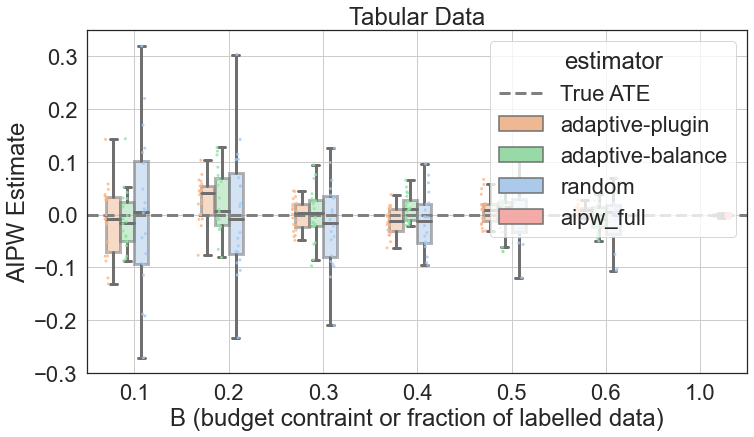

In [ ]:
#methods = ['adaptive-plugin','adaptive-balance','random']
# Plotting
plt.figure(figsize=(11, 6.6))

# Boxplots
sns.boxplot(
    x="budget",
    y="pointest",
    hue="estimator",
    data=df,
    width=0.6,
    dodge=True,
    #palette="Set2",
    showfliers=False,
    boxprops={"alpha": 0.5},  # Set transparency
)

# Overlay points
sns.stripplot(
    x="budget",
    y="pointest",
    hue="estimator",
    data=df,
    dodge=True,
    size=3,
    alpha=0.8,
    #palette=palette
    linewidth=0,
)

# Add true ATE line
plt.axhline(true_effect1, color="grey", linestyle="--", label="True ATE")
#plt.axhline(aipw_est, color="green", linestyle="--", label="AIPW ATE (Oracle)")


plt.title("Tabular Data")
plt.xlabel("B (budget contraint or fraction of labelled data)")
plt.ylabel("AIPW Estimate")
#plt.ylim(-0.5,0.8)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:5], labels[:5], 
    title="estimator", loc='upper right'
)
plt.tight_layout()
plt.grid(True)
plt.savefig("retailhero_boxplots.pdf", bbox_inches="tight")
plt.show()

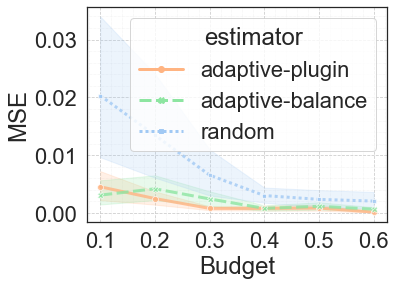

In [6]:
plt.figure(figsize=(6, 4.5))
#df['log MSE'] = np.log(df['MSE'])
sns.lineplot(data=df[df["budget"]<0.99], x='budget', y='MSE', hue='estimator',  style="estimator",  markers=True, dashes=True, alpha=0.8)
plt.ylabel("MSE")
plt.xlabel("Budget")
# set x‐ticks at each budget value
budgets = sorted(df[df["budget"] < 0.99]["budget"].unique())
plt.xticks(budgets)
plt.minorticks_on()
plt.grid(which="major", linestyle="--", linewidth=0.8)
plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

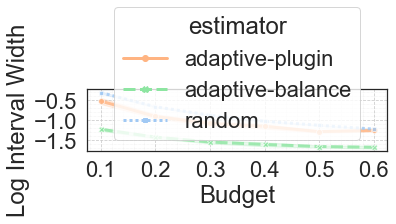

In [7]:
plt.figure(figsize=(6, 2.5))
df['log interval width'] = np.log(df['interval width'])
sns.lineplot(data=df[df["budget"]<0.99], x='budget', y='log interval width', hue='estimator', style="estimator",  markers=True, dashes=True, alpha=0.8)
plt.ylabel("Log Interval Width")
plt.xlabel("Budget")
budgets = sorted(df[df["budget"] < 0.99]["budget"].unique())
plt.xticks(budgets)
plt.minorticks_on()
plt.grid(which="major", linestyle="--", linewidth=0.8)
plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

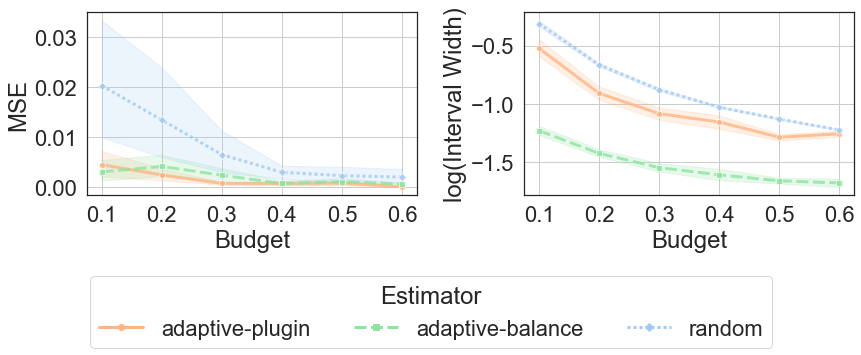

In [ ]:
# define markers per estimator
estimators = df["estimator"].unique()
marker_list = ["o", "s", "D", "^", "v", "*", "X", "P"]
marker_dict = dict(zip(estimators, marker_list))

# create side-by-side axes
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), sharex=True)

# common tick values
budgets = sorted(df[df["budget"] < 0.99]["budget"].unique())

# left plot: MSE
ax = axes[0]
sns.lineplot(
    data=df[df["budget"] < 0.99],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax, alpha=0.8
)
ax.set_xlabel("Budget")
ax.set_ylabel("MSE")
ax.set_xticks(budgets)
ax.grid(True)
#ax.set_title("MSE vs. Budget")

#  right plot: log(interval width)
ax2 = axes[1]
sns.lineplot(
    data=df[df["budget"] < 0.99],
    x="budget", y='log interval width', hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax2, alpha=0.8
)
ax2.set_xlabel("Budget")
ax2.set_ylabel("log(Interval Width)")
ax2.set_xticks(budgets)
ax2.grid(True)
#ax2.set_title("log(Interval Width) vs. Budget")

# adjust legend (one shared legend)
handles, labels = ax.get_legend_handles_labels()
# drop duplicate “estimator” title
fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.25), title="Estimator")
ax.get_legend().remove()
ax2.get_legend().remove()
plt.tight_layout(rect=[0, 0, 1, 0.9])
#fig.savefig("retailheror_lineplots.pdf", bbox_inches="tight")
plt.show()


## LLM Predictions

In [ ]:
effect = df_llm3[df_llm3['estimator']=='aipw_full']
true_effect_llm3 = np.mean(effect['pointest'])
print(true_effect_llm3)

-0.0004824044580939001


In [101]:
effect = df_llm1[df_llm1['estimator']=='aipw_full']
true_effect_llm1 = np.mean(effect['pointest'])
print(true_effect_llm1)

-0.0008099359438572997


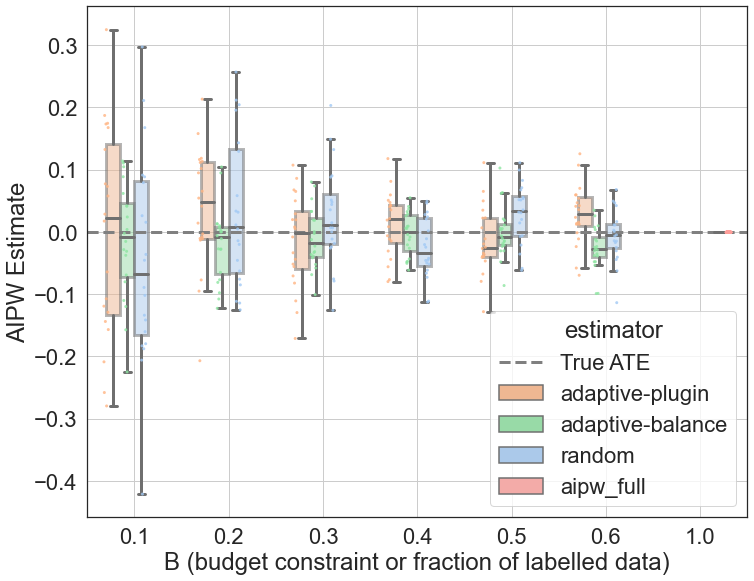

In [ ]:
#methods = ['adaptive-plugin','adaptive-balance','random']
# Plotting
plt.figure(figsize=(11, 8.6))

# Boxplots
sns.boxplot(
    x="budget",
    y="pointest",
    hue="estimator",
    data=df_llm1,
    width=0.6,
    dodge=True,
    #palette="Set2",
    showfliers=False,
    boxprops={"alpha": 0.5},  # Set transparency
)

# Overlay points
sns.stripplot(
    x="budget",
    y="pointest",
    hue="estimator",
    data=df_llm1,
    dodge=True,
    size=3,
    alpha=0.8,
    #palette=palette
    linewidth=0,
)

# Add true ATE line
plt.axhline(true_effect_llm1, color="grey", linestyle="--", label="True ATE")
#plt.axhline(aipw_est, color="green", linestyle="--", label="AIPW ATE (Oracle)")


#plt.title("Comparison of ATE Estimators")
plt.xlabel("B (budget constraint or fraction of labelled data)")
plt.ylabel("AIPW Estimate")
#plt.ylim(-0.5,0.8)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:5], labels[:5], 
    title="estimator", loc='lower right'
)
plt.tight_layout()
plt.grid(True)
plt.savefig("retailhero_boxplots_llm1.pdf", bbox_inches="tight")
plt.show()

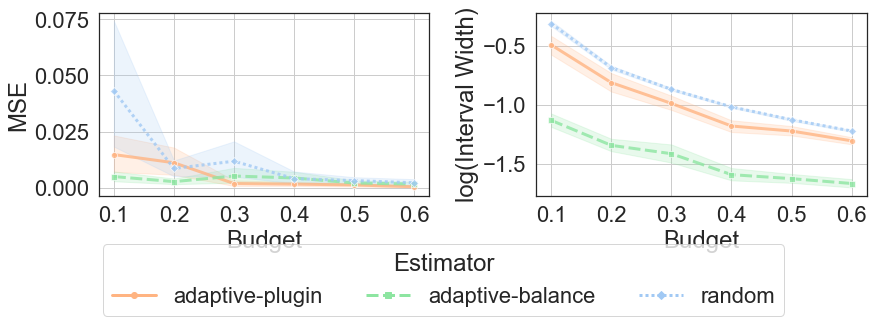

In [ ]:
# 2) define markers per estimator
estimators = df["estimator"].unique()
marker_list = ["o", "s", "D", "^", "v", "*", "X", "P"]
marker_dict = dict(zip(estimators, marker_list))

# 3) create side-by-side axes
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), sharex=True)

# common tick values
budgets = sorted(df_llm3[df_llm3["budget"] < 0.99]["budget"].unique())


ax = axes[0]
sns.lineplot(
    data=df_llm3[df_llm3["budget"] < 0.99],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax, alpha=0.8
)
ax.set_xlabel("Budget")
ax.set_ylabel("MSE")
ax.set_xticks(budgets)
ax.grid(True)
#ax.set_title("MSE vs. Budget")


ax2 = axes[1]
sns.lineplot(
    data=df_llm3[df_llm3["budget"] < 0.99],
    x="budget", y='log interval width', hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax2, alpha=0.8
)
ax2.set_xlabel("Budget")
ax2.set_ylabel("log(Interval Width)")
ax2.set_xticks(budgets)
ax2.grid(True)
#ax2.set_title("log(Interval Width) vs. Budget")

# adjust legend (one shared legend)
handles, labels = ax.get_legend_handles_labels()
# drop duplicate “estimator” title
fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.15), title="Estimator")
ax.get_legend().remove()
ax2.get_legend().remove()
plt.tight_layout(rect=[0, 0, 1, 0.9])
#fig.savefig("retailheror_lineplots_llm3.pdf", bbox_inches="tight")
plt.show()

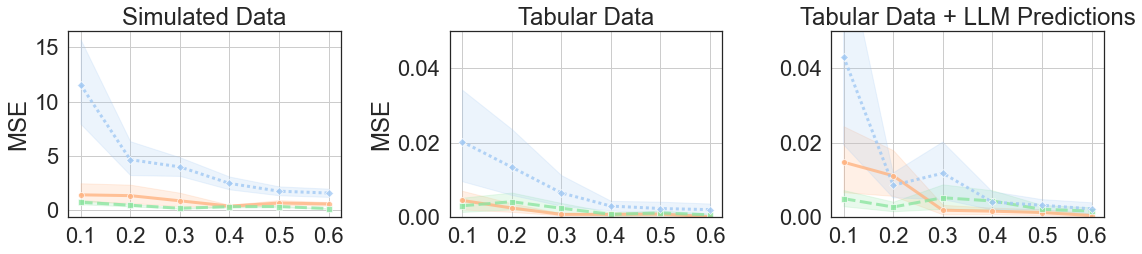

In [ ]:
estimators = df["estimator"].unique()
marker_list = ["o", "s", "D", "^", "v", "*", "X", "P"]
marker_dict = dict(zip(estimators, marker_list))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

# common tick values
budgets = sorted(df_llm3[df_llm3["budget"] < 0.99]["budget"].unique())

ax = axes[0]
sns.lineplot(
    data=df_balance[df_balance["budget"] < 0.7],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax, alpha=0.8
)
#ax.set_ylim(0,0.05)
ax.set_xlabel(None)
ax.set_ylabel("MSE")
ax.set_xticks(budgets)
ax.grid(True)
ax.set_title('Simulated Data')


ax1 = axes[1]
sns.lineplot(
    data=df[df["budget"] < 0.99],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax1, alpha=0.8
)
ax1.set_ylim(0,0.05)
ax1.set_xlabel(None)
ax1.set_ylabel("MSE")
ax1.set_xticks(budgets)
ax1.grid(True)
ax1.set_title('Tabular Data')


ax2 = axes[2]
sns.lineplot(
    data=df_llm3[df_llm3["budget"] < 0.99],
    x="budget", y='MSE', hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax2, alpha=0.8
)
ax2.set_ylim(0,0.05)
ax2.set_xlabel(None)
ax2.set_ylabel(None)
ax2.set_xticks(budgets)
ax2.grid(True)
ax2.set_title("Tabular Data + LLM Predictions")

# adjust legend (one shared legend)
handles, labels = ax.get_legend_handles_labels()
# drop duplicate “estimator” title
#fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.15), title="Estimator")
ax.get_legend().remove()
ax1.get_legend().remove()
ax2.get_legend().remove()
plt.tight_layout(rect=[0, 0, 1, 0.9])
#fig.savefig("retailhero_lineplots_llm3_mse.pdf", bbox_inches="tight")
plt.show()

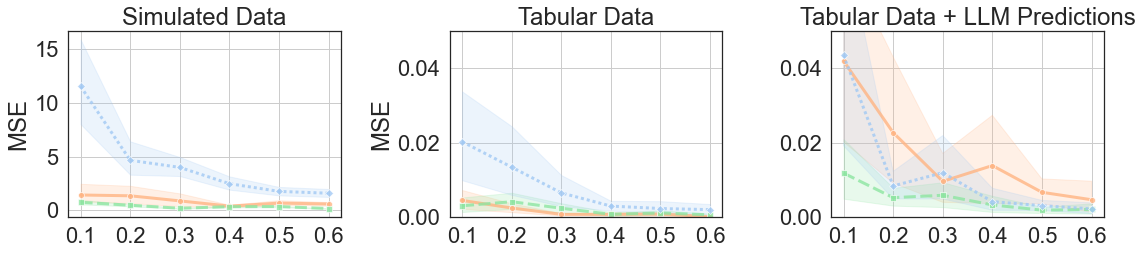

In [ ]:
estimators = df["estimator"].unique()
marker_list = ["o", "s", "D", "^", "v", "*", "X", "P"]
marker_dict = dict(zip(estimators, marker_list))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

# common tick values
budgets = sorted(df_llm3[df_llm3["budget"] < 0.99]["budget"].unique())

ax = axes[0]
sns.lineplot(
    data=df_balance[df_balance["budget"] < 0.7],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax, alpha=0.8
)
#ax.set_ylim(0,0.05)
ax.set_xlabel(None)
ax.set_ylabel("MSE")
ax.set_xticks(budgets)
ax.grid(True)
ax.set_title('Simulated Data')


ax1 = axes[1]
sns.lineplot(
    data=df[df["budget"] < 0.99],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax1, alpha=0.8
)
ax1.set_ylim(0,0.05)
ax1.set_xlabel(None)
ax1.set_ylabel("MSE")
ax1.set_xticks(budgets)
ax1.grid(True)
ax1.set_title('Tabular Data')


ax2 = axes[2]
sns.lineplot(
    data=df_llm2[df_llm2["budget"] < 0.99],
    x="budget", y='MSE', hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax2, alpha=0.8
)
ax2.set_ylim(0,0.05)
ax2.set_xlabel(None)
ax2.set_ylabel(None)
ax2.set_xticks(budgets)
ax2.grid(True)
ax2.set_title("Tabular Data + LLM Predictions")

# adjust legend (one shared legend)
handles, labels = ax.get_legend_handles_labels()
# drop duplicate “estimator” title
#fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.15), title="Estimator")
ax.get_legend().remove()
ax1.get_legend().remove()
ax2.get_legend().remove()
plt.tight_layout(rect=[0, 0, 1, 0.9])
#fig.savefig("retailhero_lineplots_llm3_mse.pdf", bbox_inches="tight")
plt.show()

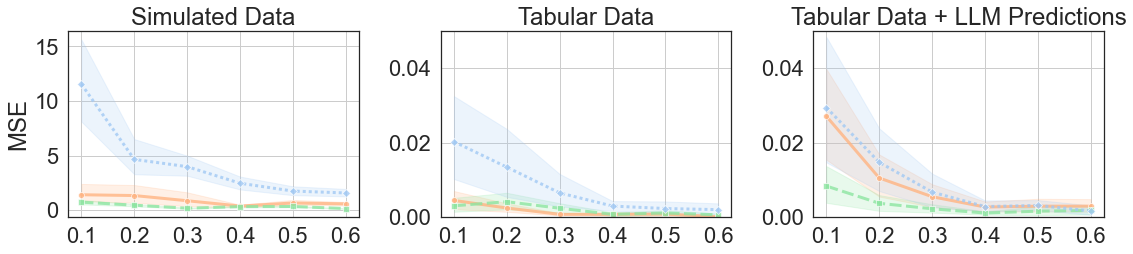

In [ ]:
estimators = df["estimator"].unique()
marker_list = ["o", "s", "D", "^", "v", "*", "X", "P"]
marker_dict = dict(zip(estimators, marker_list))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

# common tick values
budgets = sorted(df_llm3[df_llm3["budget"] < 0.99]["budget"].unique())

ax = axes[0]
sns.lineplot(
    data=df_balance[df_balance["budget"] < 0.7],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax, alpha=0.8
)
#ax.set_ylim(0,0.05)
ax.set_xlabel(None)
ax.set_ylabel("MSE")
ax.set_xticks(budgets)
ax.grid(True)
ax.set_title('Simulated Data')


ax1 = axes[1]
sns.lineplot(
    data=df[df["budget"] < 0.99],
    x="budget", y="MSE", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax1, alpha=0.8
)
ax1.set_ylim(0,0.05)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticks(budgets)
ax1.grid(True)
ax1.set_title('Tabular Data')


ax2 = axes[2]
sns.lineplot(
    data=df_llm1[df_llm1["budget"] < 0.99],
    x="budget", y='MSE', hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax2, alpha=0.8
)
ax2.set_ylim(0,0.05)
ax2.set_xlabel(None)
ax2.set_ylabel(None)
ax2.set_xticks(budgets)
ax2.grid(True)
ax2.set_title("Tabular Data + LLM Predictions")

# adjust legend (one shared legend)
handles, labels = ax.get_legend_handles_labels()
# drop duplicate “estimator” title
#fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.15), title="Estimator")
ax.get_legend().remove()
ax1.get_legend().remove()
ax2.get_legend().remove()
plt.tight_layout(rect=[0, 0, 1, 0.9])
fig.savefig("synthetic_lineplots_llm1_mse.pdf", bbox_inches="tight")
plt.show()

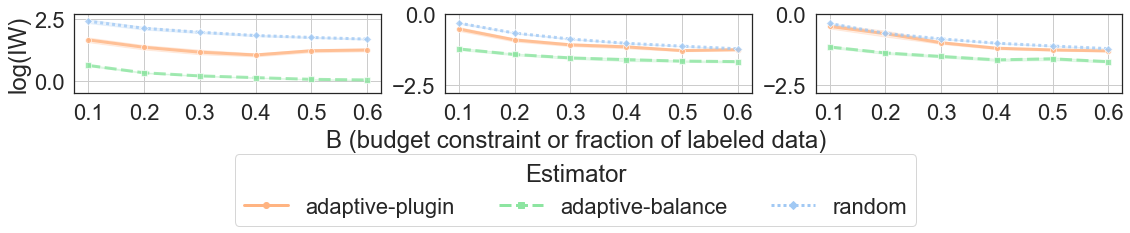

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 2.6), sharex=True)

# common tick values
budgets = sorted(df_llm3[df_llm3["budget"] < 0.99]["budget"].unique())

ax = axes[0]
sns.lineplot(
    data=df_balance[df_balance["budget"] < 0.7],
    x="budget", y="log interval width", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax, alpha=0.8
)
ax.set_ylim(-0.5,2.7)
ax.set_xlabel(None)
ax.set_ylabel("log(IW)")
ax.set_xticks(budgets)
ax.grid(True)
#ax.set_title("MSE vs. Budget")

ax1 = axes[1]
sns.lineplot(
    data=df[df["budget"] < 0.99],
    x="budget", y="log interval width", hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax1, alpha=0.8
)
ax1.set_ylim(-2.8,0)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticks(budgets)
ax1.grid(True)


ax2 = axes[2]
sns.lineplot(
    data=df_llm1[df_llm1["budget"] < 0.99],
    x="budget", y='log interval width', hue="estimator", style="estimator",
    markers=marker_dict, dashes=True, ax=ax2, alpha=0.8
)
ax2.set_ylim(-2.8,0)
ax2.set_xlabel(None)
ax2.set_ylabel(None)
ax2.set_xticks(budgets)
ax2.grid(True)
#ax2.set_title("log(Interval Width) vs. Budget")
fig.text(0.5, 0.01, 'B (budget constraint or fraction of labeled data)', ha='center')
# adjust legend (one shared legend)
handles, labels = ax.get_legend_handles_labels()
# drop duplicate “estimator” title
fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.47), title="Estimator")
ax.get_legend().remove()
ax1.get_legend().remove()
ax2.get_legend().remove()
plt.tight_layout(rect=[0, 0, 1, 0.9])
fig.savefig("synthetic_lineplots_llm1_logiw.pdf", bbox_inches="tight")
plt.show()

## Budget Saved plots

In [ ]:
def make_dual_budget_plots(
    df1, df2,
    titles=("Dataset 1", "Dataset 2"),
    filename="dual_budget_savings.png",
    include_ylabel=True
):
    """
    Create side-by-side plots of budget savings for two datasets.
    Inputs:
        - df1, df2: two DataFrames with columns ['estimator','budget','interval width']
        - titles:   tuple of subplot titles
        - filename: where to save the combined figure and filename
    Outputs:
        - prints figure and saves figure to folder specified by filename
        - returns figure and axes objects 

    """

    def prepare_savings(df):
        # names must match your df.estimator entries exactly
        baseline = "random"
        plugin   = "adaptive-plugin"
        balance  = "adaptive-balance"

        # sorted budgets
        budgets = np.sort(df["budget"].unique())

        # mean widths per estimator
        mean_width = {}
        for est in (baseline, plugin, balance):
            mean_width[est] = (
                df[df.estimator == est]
                  .groupby("budget")["interval width"]
                  .mean()
                  .reindex(budgets)
                  .values
            )

        # compute savings for plugin or balance vs baseline
        def compute_sav(alt, base):
            ns, saves = [], []
            for n, w_alt in zip(budgets, alt):
                # extrapolate or interpolate
                if w_alt > base[0]:
                    j0, j1 = 0, 1
                elif w_alt < base[-1]:
                    j0, j1 = len(budgets)-2, len(budgets)-1
                else:
                    idxs = np.where(base >= w_alt)[0]
                    j0 = idxs[-1]
                    j1 = j0 + 1

                b0, b1 = budgets[j0], budgets[j1]
                w0, w1 = base[j0], base[j1]
                baseline_n = b0 + (w_alt - w0)/(w1 - w0)*(b1 - b0)
                saves.append((baseline_n - n)/baseline_n*100)
                ns.append(n)

            return np.array(ns), np.array(saves)

        ns_p, save_p = compute_sav(mean_width[plugin],  mean_width[baseline])
        ns_b, save_b = compute_sav(mean_width[balance], mean_width[baseline])
        return (ns_p, save_p), (ns_b, save_b)

    # prepare both datasets
    (ns1_p, sv1_p), (ns1_b, sv1_b) = prepare_savings(df1)
    (ns2_p, sv2_p), (ns2_b, sv2_b) = prepare_savings(df2)

    # create side-by-side subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, (ns_p, sv_p, ns_b, sv_b), title in zip(
        axs,
        [(ns1_p, sv1_p, ns1_b, sv1_b), (ns2_p, sv2_p, ns2_b, sv2_b)],
        titles
    ):
        ax.plot(ns_p, sv_p, marker="o", linestyle="--",
                label="adaptive-plugin")
        ax.plot(ns_b, sv_b, marker="s", linestyle="--",
                label="adaptive-balance")
        ax.set_title(title)
        ax.set_xlabel(None)
        #ax.set_ylim(0, 100)
        ax.set_yticks([0,25,50,75,100])
        if include_ylabel:
            ax.set_ylabel("Budget Saved (%) \n Over Random")
        ax.yaxis.set_major_formatter(FormatStrFormatter("%d%%"))
        ax.grid(True)
        #ax.get_legend().remove()
    fig.text(0.5, 0.01, 'B (budget constraint or fraction of labeled data)', ha='center')
    # 6) adjust legend (one shared legend)
    handles, labels = ax.get_legend_handles_labels()
    # drop duplicate “estimator” title
    fig.legend(handles, labels, loc="lower center", ncol=len(estimators),bbox_to_anchor=(0.5, -0.3), title="Estimator")
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    return fig, axs


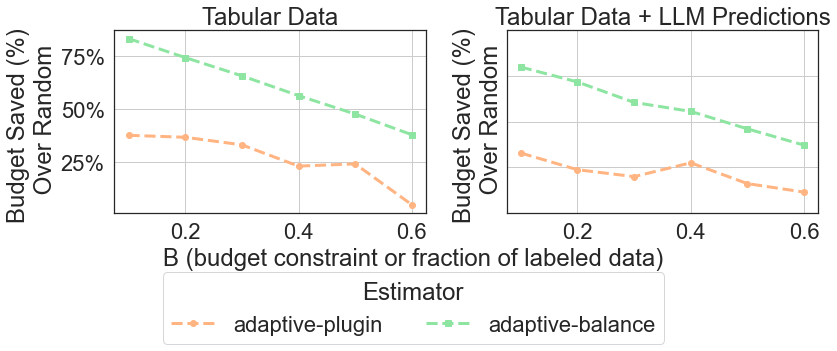

In [95]:
fig, axs = make_dual_budget_plots(
    df1=df[df["estimator"]!='aipw_full'],
    df2=df_llm3[df_llm3['estimator']!='aipw_full'],
    titles=("Tabular Data", "Tabular Data + LLM Predictions"),
    filename="retailhero_budgetsaved.png"
)
